In [25]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [26]:
class AgentState(TypedDict):
    name : str
    age : int
    msg : str

In [27]:
def Greetings(state: AgentState) -> AgentState: 
    s1 = f"Hi {state['name']}, Good Evening."
    state['msg'] = s1
    return state


In [28]:
def Greetings1(state: AgentState) -> AgentState:
    state['msg'] = state['msg'] + f"Your age is {state['age']}"
    return state

In [29]:
graph = StateGraph(AgentState)
graph.add_node("node1", Greetings) 
graph.add_node("node2", Greetings1)
graph.add_edge("node1", "node2") 
graph.set_entry_point("node1") 
graph.set_finish_point("node2") 
app = graph.compile()

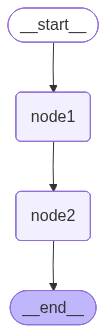

In [30]:

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [31]:
app.invoke({
    'name' : 'Amandeep Singh',
    'age' : 22
})

{'name': 'Amandeep Singh',
 'age': 22,
 'msg': 'Hi Amandeep Singh, Good Evening.Your age is 22'}

In [32]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [33]:
class AgentState(TypedDict):
    num1 : int 
    num2 : int 
    opr : str
    result : int 
    

In [34]:
def adder(state: AgentState)-> AgentState:
    state['result'] = state['num1'] + state['num2']
    return state

def subtractor(state: AgentState)->AgentState:
    state['result'] = state['num1'] - state['num2']
    return state

def conditional_node(state: AgentState)-> AgentState:
    return state

def decider_func(state: AgentState)-> str:

    if(state['opr'] == "+"):
        return "addition_edge"
    elif(state['opr'] == "-"):
        return "substraction_edge"



In [35]:
graph = StateGraph(AgentState)
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("conditional_node", conditional_node)
graph.set_entry_point("conditional_node")
graph.add_conditional_edges(
    "conditional_node",
    decider_func,
    {
        "addition_edge" : "add_node",
        "subtraction_edge" : "subtract_node"
    }
)

graph.set_finish_point("add_node")
graph.set_finish_point("subtract_node")

app = graph.compile

In [36]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

AttributeError: 'function' object has no attribute 'get_graph'

In [ ]:
app.invoke({
    "num1" : 13,
    "num2" : 34,
    "opr" : "-" 
})

AttributeError: 'function' object has no attribute 'invoke'

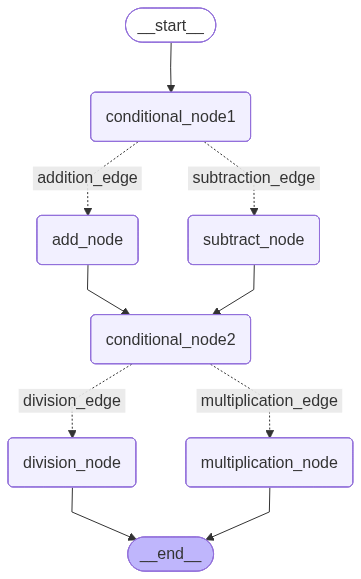

{'num1': 10,
 'num2': 20,
 'num3': 5,
 'operation1': '+',
 'operation2': '*',
 'result1': 30,
 'final_result': 150}

In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    num1 : int
    num2 : int
    num3 : int
    operation1 : str
    operation2 : str
    result1 : int
    final_result : int
def addition(state : AgentState) -> AgentState:
    state['result1'] = state['num1'] + state['num2']
    return state
def subtraction(state : AgentState) -> AgentState:
    state['result1'] = state['num1'] - state['num2']
    return state
def division(state : AgentState) -> AgentState:
    state['final_result'] = state['result1'] / state['num3']
    return state
def multiplication(state : AgentState) -> AgentState:
    state['final_result'] = state['result1'] * state['num3']
    return state
def conditional_node1(state : AgentState) -> AgentState:
    return state

def decider_function1(state : AgentState) -> str:
    if (state['operation1'] == '+'):
        return "addition_edge"
    else:
        return "subtraction_edge"
def conditional_node2(state : AgentState) -> AgentState:
    return state

def decider_function2(state : AgentState) -> str:
    if (state['operation2'] == '*'):
        return "multiplication_edge"
    else:
        return "division_edge"
graph = StateGraph(AgentState)
graph.add_node("add_node", addition)
graph.add_node("subtract_node", subtraction)
graph.add_node("division_node", division)
graph.add_node("multiplication_node", multiplication)
graph.add_node("conditional_node1", conditional_node1)
graph.add_node("conditional_node2", conditional_node2)

graph.add_edge("add_node", "conditional_node2")
graph.add_edge("subtract_node", "conditional_node2")


graph.set_entry_point("conditional_node1")

graph.add_conditional_edges(
    "conditional_node1",
    decider_function1,
    {
        "addition_edge" : "add_node",
        "subtraction_edge" : "subtract_node"
    }
)

graph.add_conditional_edges(
    "conditional_node2",
    decider_function2,
    {
        "division_edge" : "division_node",
        "multiplication_edge" : "multiplication_node"
    }
)


graph.set_finish_point("division_node")
graph.set_finish_point("multiplication_node")
app = graph.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))
app.invoke({
    'num1' : 10,
    'num2' : 20,
    'operation1' : '+',
    'num3' : 5,
    'operation2' : '*'
})